In [20]:
import os
os.environ['TZ'] = 'Europe/Berlin'
 
import re
import numpy as np
import anndata as ad
import pandas as pd
import scanpy as sc 
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
from adjustText import adjust_text

In [2]:
BASE = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune"
OUT_DIR = f"{BASE}/results/10_integration_GBM_HIHA"
os.makedirs(OUT_DIR, exist_ok=True)

In [3]:
adata = sc.read_h5ad(f"{BASE}/data/10_integration_GBM_HIHA/gbmap_hiha_concat_harmony.h5ad")
print("Loaded:", adata.shape)

mp_scores = pd.read_csv("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/09_HIHAtlas/09_03_nmf_downsampled/mp_scores_healthy.csv", index_col=0)


Loaded: (208945, 22586)


In [4]:
THRESHOLD = 1.0

if "condition" in adata.obs.columns:
    condition_col = "condition"
elif "dataset" in adata.obs.columns:
    label_map = {"HIHAtlas": "Healthy", "GBMap": "GBM"}
    adata.obs["condition"] = adata.obs["dataset"].map(label_map)
    condition_col = "condition"
else:
    raise ValueError("Neither 'condition' nor 'dataset' found in adata.obs.")

score_cols_native = [c for c in mp_scores.columns if re.match(r"MP\d+_score$", c)]
adata_barcodes_stripped = adata.obs_names.str.replace(r"-HIHAtlas$", "", regex=True)
aligned = mp_scores[score_cols_native].reindex(adata_barcodes_stripped)
aligned.index = adata.obs_names
for col in score_cols_native:
    adata.obs[col] = aligned[col].values
 
mp5_candidates = [c for c in adata.obs.columns if re.match(r"(HIHA_)?MP5_score$", c)]
mp5_col = mp5_candidates[0]
 
celltype_col = "decoupler_level1_celltype"
pdc_label = "pDC"

healthy_pdc = adata[
    (adata.obs[condition_col] == "Healthy") & (adata.obs[celltype_col] == pdc_label)
].copy()
healthy_pdc = healthy_pdc[healthy_pdc.obs[mp5_col].notna()].copy()
 
healthy_pdc.obs["MP5_group"] = pd.Categorical(
    (healthy_pdc.obs[mp5_col] >= THRESHOLD).map({True: "MP5_high", False: "MP5_low"}),
    categories=["MP5_low", "MP5_high"],
)
print("Healthy pDC subset:", healthy_pdc.shape)
print(healthy_pdc.obs["MP5_group"].value_counts())


Healthy pDC subset: (8738, 22586)
MP5_group
MP5_high    4584
MP5_low     4154
Name: count, dtype: int64


### parse the GMT file, keep only interferon alpha/beta/gamma terms

In [5]:
def read_gmt(path):
    """Minimal GMT parser: term \\t description \\t gene1 \\t gene2 ..."""
    gene_sets = {}
    with open(path) as f:
        for line in f:
            fields = line.rstrip("\n").split("\t")
            if len(fields) < 3:
                continue
            term, _, *genes = fields
            gene_sets[term] = [g for g in genes if g]
    return gene_sets


all_gene_sets = read_gmt("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/c5.go.bp.v2026.1.Hs.symbols.gmt")
print(f"Loaded {len(all_gene_sets)} total gene sets")

IFN_PATTERN = re.compile(
    r"INTERFERON.*(ALPHA|BETA|GAMMA)|TYPE_(I|II)_INTERFERON|IFN.?(A|B|G)(?!\w)",
    re.IGNORECASE,
)
ifn_terms = {term: genes for term, genes in all_gene_sets.items() if IFN_PATTERN.search(term)}
 
print(f"\n{len(ifn_terms)} interferon alpha/beta/gamma terms matched:")
for term in sorted(ifn_terms):
    print(f"  {term}  ({len(ifn_terms[term])} genes)")
 
if not ifn_terms:
    raise ValueError(
        "No interferon alpha/beta/gamma terms matched. Print a sample of "
        "all_gene_sets.keys() and adjust IFN_PATTERN to match the actual "
        "naming convention in this GMT file."
    )


Loaded 7538 total gene sets

27 interferon alpha/beta/gamma terms matched:
  GOBP_CELLULAR_RESPONSE_TO_INTERFERON_ALPHA  (11 genes)
  GOBP_CELLULAR_RESPONSE_TO_INTERFERON_BETA  (30 genes)
  GOBP_CELLULAR_RESPONSE_TO_TYPE_II_INTERFERON  (101 genes)
  GOBP_INTERFERON_ALPHA_PRODUCTION  (32 genes)
  GOBP_INTERFERON_BETA_PRODUCTION  (64 genes)
  GOBP_NEGATIVE_REGULATION_OF_INTERFERON_ALPHA_PRODUCTION  (6 genes)
  GOBP_NEGATIVE_REGULATION_OF_INTERFERON_BETA_PRODUCTION  (17 genes)
  GOBP_NEGATIVE_REGULATION_OF_RESPONSE_TO_TYPE_II_INTERFERON  (8 genes)
  GOBP_NEGATIVE_REGULATION_OF_TYPE_II_INTERFERON_PRODUCTION  (46 genes)
  GOBP_NEGATIVE_REGULATION_OF_TYPE_I_INTERFERON_MEDIATED_SIGNALING_PATHWAY  (23 genes)
  GOBP_NEGATIVE_REGULATION_OF_TYPE_I_INTERFERON_PRODUCTION  (53 genes)
  GOBP_POSITIVE_REGULATION_OF_INTERFERON_ALPHA_PRODUCTION  (26 genes)
  GOBP_POSITIVE_REGULATION_OF_INTERFERON_BETA_PRODUCTION  (43 genes)
  GOBP_POSITIVE_REGULATION_OF_RESPONSE_TO_TYPE_II_INTERFERON  (6 genes)
  GOBP_P

### score every Healthy pDC on each IFN pathways

In [6]:
scored_cols = []
for term, genes in ifn_terms.items():
    genes_in_data = [g for g in genes if g in healthy_pdc.var_names]
    if len(genes_in_data) < 5:
        print(f"[{term}] only {len(genes_in_data)} genes present in data - "
              f"skipping (too few for a reliable score)")
        continue
    if len(genes_in_data) < len(genes):
        print(f"[{term}] {len(genes) - len(genes_in_data)} of {len(genes)} "
              f"genes not found in var_names, using remaining {len(genes_in_data)}")
 
    score_name = f"{term}_score"
    sc.tl.score_genes(healthy_pdc, gene_list=genes_in_data, score_name=score_name, random_state=42)
    scored_cols.append(score_name)
 
print(f"\nScored {len(scored_cols)} IFN pathways on {healthy_pdc.n_obs} Healthy pDCs")


[GOBP_CELLULAR_RESPONSE_TO_INTERFERON_BETA] 2 of 30 genes not found in var_names, using remaining 28
[GOBP_CELLULAR_RESPONSE_TO_TYPE_II_INTERFERON] 4 of 101 genes not found in var_names, using remaining 97
[GOBP_INTERFERON_BETA_PRODUCTION] 1 of 64 genes not found in var_names, using remaining 63
[GOBP_NEGATIVE_REGULATION_OF_INTERFERON_BETA_PRODUCTION] 1 of 17 genes not found in var_names, using remaining 16
[GOBP_NEGATIVE_REGULATION_OF_TYPE_II_INTERFERON_PRODUCTION] 4 of 46 genes not found in var_names, using remaining 42
[GOBP_NEGATIVE_REGULATION_OF_TYPE_I_INTERFERON_MEDIATED_SIGNALING_PATHWAY] 2 of 23 genes not found in var_names, using remaining 21
[GOBP_NEGATIVE_REGULATION_OF_TYPE_I_INTERFERON_PRODUCTION] 2 of 53 genes not found in var_names, using remaining 51
[GOBP_POSITIVE_REGULATION_OF_TYPE_II_INTERFERON_PRODUCTION] 9 of 90 genes not found in var_names, using remaining 81
[GOBP_POSITIVE_REGULATION_OF_TYPE_I_INTERFERON_PRODUCTION] 1 of 79 genes not found in var_names, using rema

In [7]:
out_df = healthy_pdc.obs[[mp5_col, "MP5_group"] + scored_cols].copy()
out_df.index.name = "barcode"
out_csv = os.path.join(OUT_DIR, "10_11_ifn_pathway_scores_pDC.csv")
out_df.reset_index().to_csv(out_csv, index=False)
print(f"Saved per-cell IFN pathway scores to {out_csv}")

Saved per-cell IFN pathway scores to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_11_ifn_pathway_scores_pDC.csv


### Mann-Whitney U test per pathway: MP5_high scores vs MP5_low scores

In [8]:
high_mask = out_df["MP5_group"] == "MP5_high"
low_mask = out_df["MP5_group"] == "MP5_low"
 
test_rows = []
for score_col in scored_cols:
    term = score_col[: -len("_score")]
    high_vals = out_df.loc[high_mask, score_col]
    low_vals = out_df.loc[low_mask, score_col]
    stat, pval = mannwhitneyu(high_vals, low_vals, alternative="two-sided")
    test_rows.append({
        "term": term,
        "mean_MP5_high": high_vals.mean(),
        "mean_MP5_low": low_vals.mean(),
        "mean_diff": high_vals.mean() - low_vals.mean(),
        "n_MP5_high": len(high_vals),
        "n_MP5_low": len(low_vals),
        "U_stat": stat,
        "pval": pval,
    })
 
test_df = pd.DataFrame(test_rows)
test_df["padj"] = multipletests(test_df["pval"], method="fdr_bh")[1]
test_df = test_df.sort_values("mean_diff", key=lambda s: s.abs(), ascending=False)
 
out_test_csv = os.path.join(OUT_DIR, "10_11_pDC_IFN_mannwhitneyu_MP5.csv")
test_df.to_csv(out_test_csv, index=False)
print(f"Saved Mann-Whitney results to {out_test_csv}")
 
print("\nIFN pathway scores, MP5_high vs MP5_low (sign: positive mean_diff = higher in MP5_high):")
print(test_df.to_string(index=False))

Saved Mann-Whitney results to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_11_pDC_IFN_mannwhitneyu_MP5.csv

IFN pathway scores, MP5_high vs MP5_low (sign: positive mean_diff = higher in MP5_high):
                                                                    term  mean_MP5_high  mean_MP5_low  mean_diff  n_MP5_high  n_MP5_low     U_stat          pval          padj
                 GOBP_NEGATIVE_REGULATION_OF_INTERFERON_ALPHA_PRODUCTION       0.000046     -0.245622   0.245668        4584       4154 17080437.0  0.000000e+00  0.000000e+00
                                        GOBP_INTERFERON_ALPHA_PRODUCTION       0.188894      0.073328   0.115566        4584       4154 16483919.0  0.000000e+00  0.000000e+00
                GOBP_NEGATIVE_REGULATION_OF_TYPE_I_INTERFERON_PRODUCTION       0.167404      0.072369   0.095035        4584       4154 16123254.0  0.000000e+00  0.000000e+00
              GOBP_NEGATIVE_REGULATION_OF_RESPONSE_TO_TY

In [9]:
len(test_df)

27

## Volcano plot - IFN highlited

In [ ]:
PADJ_SIG_LINE = 0.05
 
# same pattern as above
IFN_PATTERN = re.compile(
    r"INTERFERON.*(ALPHA|BETA|GAMMA)|TYPE_(I|II)_INTERFERON|IFN.?(A|B|G)(?!\w)",
    re.IGNORECASE,
)

In [21]:
GSEA_RESULTS_PATH = f"/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_09_GSEA_pDC_MP5/10_09_prerank_pDC_MP5_GO/gseapy.gene_set.prerank.report.csv"
res_df = pd.read_csv(GSEA_RESULTS_PATH)
print(f"Loaded {len(res_df)} GO BP terms")
print(res_df.columns.tolist())
 
res_df["NES"] = res_df["NES"].astype(float)
res_df["FDR q-val"] = res_df["FDR q-val"].astype(float)
 
# avoid log10(0) for terms with padj exactly 0 - clip to the smallest
# nonzero padj in the data instead of an arbitrary constant
min_nonzero_padj = res_df.loc[res_df["FDR q-val"] > 0, "FDR q-val"].min()
res_df["neg_log10_padj"] = -np.log10(res_df["FDR q-val"].clip(lower=min_nonzero_padj))
 
is_ifn = res_df["Term"].astype(str).apply(lambda t: bool(IFN_PATTERN.search(t)))
print(f"{is_ifn.sum()} interferon alpha/beta/gamma terms matched")

Loaded 7239 GO BP terms
['Name', 'Term', 'ES', 'NES', 'NOM p-val', 'FDR q-val', 'FWER p-val', 'Tag %', 'Gene %', 'Lead_genes']
27 interferon alpha/beta/gamma terms matched


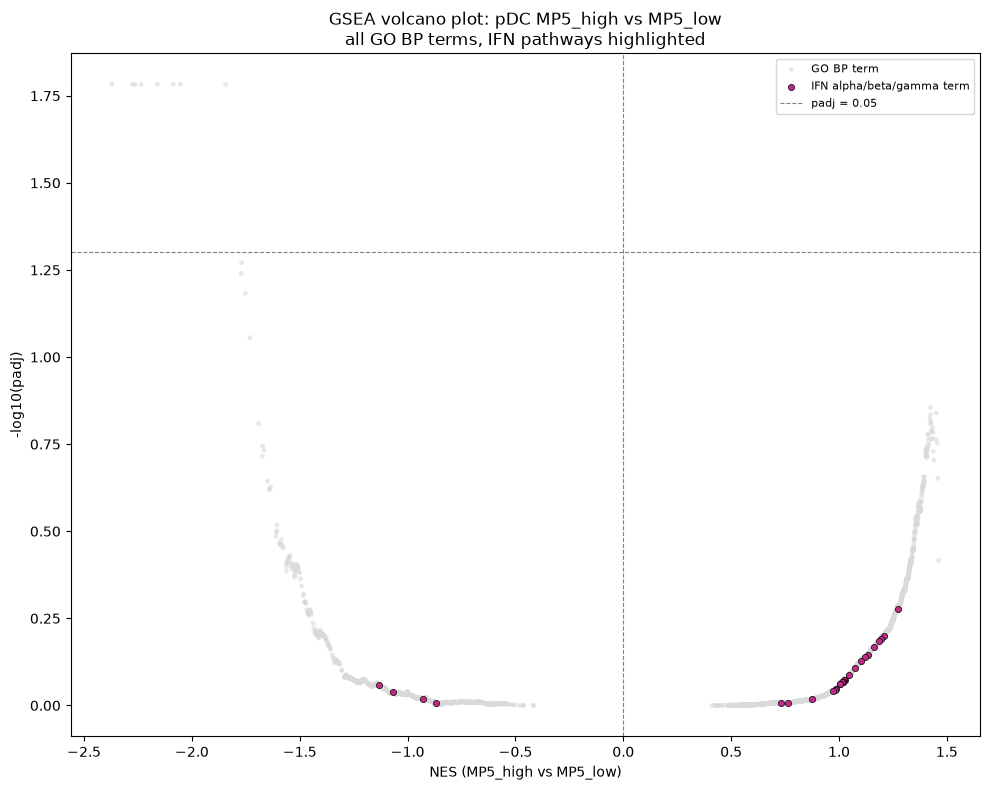


Saved volcano plot to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_11_volcano_gsea_pDC_MP5_IFN_highlight.pdf


In [27]:
fig, ax = plt.subplots(figsize=(10, 8))
 
ax.scatter(res_df.loc[~is_ifn, "NES"], res_df.loc[~is_ifn, "neg_log10_padj"],
           s=12, color="#D9D9D9", edgecolor="none", alpha=0.6, label="GO BP term")
 
ax.scatter(res_df.loc[is_ifn, "NES"], res_df.loc[is_ifn, "neg_log10_padj"],
           s=20, color="#C02B87", edgecolor="black", linewidth=0.5,
           label="IFN alpha/beta/gamma term")
 
ax.axhline(-np.log10(PADJ_SIG_LINE), color="grey", linestyle="--", linewidth=0.8,
           label=f"padj = {PADJ_SIG_LINE}")
ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)
 
ax.set_xlabel("NES (MP5_high vs MP5_low)")
ax.set_ylabel("-log10(padj)")
ax.set_title("GSEA volcano plot: pDC MP5_high vs MP5_low\nall GO BP terms, IFN pathways highlighted")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
 
out_pdf = os.path.join(OUT_DIR, "10_11_volcano_gsea_pDC_MP5_IFN_highlight.pdf")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show(fig)
plt.close(fig)
print(f"\nSaved volcano plot to {out_pdf}")

- Very positive NES: the pathway's genes are strongly concentrated among the genes ranked highest — i.e. genes most upregulated in MP5_high. The pathway is strongly "turned on" (or at least strongly shifted) in the MP5_high group relative to MP5_low.
- Very negative NES: the opposite — the pathway's genes cluster among the genes most upregulated in MP5_low, so the pathway is strongly shifted toward MP5_low.
- NES near 0: no strong directional pattern — the pathway's genes are scattered roughly evenly across the ranked list, not concentrated at either end.